# Channel-level $C_G$ pilot: noise-induced symmetry breaking in equivariant quantum channels

**Channel-Level Diagnostic for Symmetry Breaking in Noisy Equivariant Quantum Neural Networks
by H. Ugail and N. Howard**

## Definitions used here

For a quantum channel $\mathcal{E}$ with Liouville (superoperator) representation
$\Phi_\mathcal{E}$ and a group $G$ acting on the Hilbert space by unitaries
$\{U_g\}$, write $\Phi_g = U_g \otimes U_g^*$ (row-major vec convention). Define

$$
\Delta_G(\mathcal{E}) \;=\; \mathbb{E}_{g \sim G}\!\left[
  \frac{\lVert \Phi_\mathcal{E}\Phi_g - \Phi_g\Phi_\mathcal{E} \rVert_F}
       {2\,\lVert \Phi_\mathcal{E}\rVert_F\,\lVert \Phi_g\rVert_F}
\right],
\qquad
C_G(\mathcal{E}) \;=\; \exp\!\bigl(-\gamma\, \Delta_G(\mathcal{E})\bigr).
$$

The normalisation puts $\Delta_G \in [0,1]$, so $C_G \in [e^{-\gamma}, 1]$. The
**lemma** the manuscript would prove, stated informally:
$C_G(\mathcal{E}) = 1$ if and only if $\Phi_\mathcal{E}$ commutes with every
$\Phi_g$ on the tested representation. The pilot checks both the lemma
(Section 5, R1–R3) and how $C_G$ degrades under three noise families
(Sections 3–4 and 6).

## Pre-registered decision rules

**Diagnostic correctness (V1–V10).** Sanity controls on $U(1)$ and $SU(2)$.

| Check | Setting | Required |
|-------|---------|----------|
| V1 | $U(1)$, identity channel | $C_G \ge 0.99$ |
| V2 | $U(1)$, Haar-random unitary channel | $C_G \le 0.60$ |
| V3 | $U(1)$, depolarising at $p=0.3$ | $C_G \ge 0.99$ |
| V4 | $U(1)$, amplitude damping at $\varepsilon=0.3$ | $C_G \ge 0.99$ |
| V5 | $U(1)$, coherent $X$ rotation at $\varepsilon=0.3$ | $C_G \le 0.70$ |
| V6 | $SU(2)$, identity channel | $C_G \ge 0.99$ |
| V7 | $SU(2)$, Haar-random unitary channel | $C_G \le 0.60$ |
| V8 | $SU(2)$, depolarising at $p=0.3$ | $C_G \ge 0.99$ |
| V9 | $SU(2)$, amplitude damping at $\varepsilon=0.3$ | $C_G \le 0.85$ |
| V10 | $SU(2)$, coherent $X$ on qubit 0 at $\varepsilon=0.3$ | $C_G \le 0.70$ |

**Note on V4 versus V9.** Amplitude damping commutes with phase rotations
$e^{i\theta n}$ at the channel level, even though it does not preserve charge
expectation. So $C_G$ should remain at unity for $U(1)$ but drop for $SU(2)$.
The contrast is itself a positive scientific finding for the manuscript.

**Robustness (R1–R9).** Defensibility against the obvious reviewer pushes.

| Check | What it tests | Required |
|-------|---------------|----------|
| R1 | $\Delta_G$ machine-zero on every equivariant case | $\Delta_G < 10^{-10}$ |
| R2 | Non-trivial $U(1)$-equivariant unitary, not just identity | $\Delta_G < 10^{-10}$ |
| R3 | Non-trivial $SU(2)$-equivariant unitary, not just identity | $\Delta_G < 10^{-10}$ |
| R4 | $U(1)$ Haar baseline robust across all seeds | every seed $C_G \le 0.60$ |
| R5 | $SU(2)$ Haar baseline robust across all seeds | every seed $C_G \le 0.60$ |
| R6 | $SU(2)$ Haar sampling stability on multiple channels | rel. std $< 5\%$ at $n=50$ |
| R7 | Dimension-invariant separation at $n=3$ qubits | equivariant $< 10^{-10}$, breaking $> 10^{-3}$ |
| R8 | Every Kraus channel used is CPTP | trace-preserving to $10^{-10}$ |
| R9 | Channel ranking unchanged under operator norm | ordering matches Frobenius |

The pilot reports **GO** only if both V1–V10 and R1–R9 clear.

## Section 1: imports and configuration

In [ ]:
import os
from itertools import product as iprod

import numpy as np
import scipy.linalg as la
from scipy.stats import unitary_group
import matplotlib.pyplot as plt
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')


CFG = {
    # System sizes
    "n_qubits_u1":      2,
    "n_qubits_u1_R7":   3,
    "n_qubits_su2":     2,
    # Group sampling
    "n_u1_samples":     30,
    "n_su2_samples":    50,
    # Noise sweeps
    "n_eps":            21,
    "eps_max":          0.3,
    # Random baseline
    "n_random_seeds":   10,
    # Compliance temperature
    "gamma":            5.0,
    "gamma_grid":       [2.0, 5.0, 10.0],
    # Reproducibility
    "rng_seed":         42,
    # Robustness thresholds
    "machine_zero":     1e-10,
    "relstd_threshold": 0.05,
    "tp_atol":          1e-10,
    # Output
    "fig_dir":          "/content/drive/MyDrive/",
    "data_dir":         "/content/drive/MyDrive/../results",
}

os.makedirs(CFG["fig_dir"], exist_ok=True)
os.makedirs(CFG["data_dir"], exist_ok=True)

print(f"Config loaded. gamma = {CFG['gamma']}, n_eps = {CFG['n_eps']}, "
      f"U(1) samples = {CFG['n_u1_samples']}, SU(2) samples = {CFG['n_su2_samples']}.")

# ---- Production-quality figure settings (IEEE Access two-column) ----
# 300 dpi PNG output, sans-serif, sizes legible at printed dimensions.
# Single-column figures: 3.5 in wide. Double-column figures: 7.16 in wide.
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size":        9,
    "axes.labelsize":   10,
    "axes.titlesize":   10,
    "legend.fontsize":  8,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "axes.linewidth":   0.8,
    "lines.linewidth":  1.4,
    "lines.markersize": 4.5,
    "savefig.bbox":     "tight",
    "savefig.dpi":      300,
    "figure.dpi":       110,
})
DOUBLE_COL = 7.16   # IEEE double-column width, inches
SINGLE_COL = 3.5    # IEEE single-column width, inches

def save_paper_figure(fig, name):
    """Save a figure as a 300-dpi PNG named <name>.png in CFG['fig_dir']."""
    path = os.path.join(CFG["fig_dir"], f"{name}.png")
    fig.savefig(path, dpi=300)
    print(f"  wrote {path}")


## Section 1.5: paper Figure 1 — method workflow schematic

A pure-illustration figure showing the five stages of the channel-level compliance audit. No data inputs; this cell can be run anywhere in the notebook.

In [ ]:
# ---- Paper Figure 1: method workflow schematic ----
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 2.2))
ax.set_xlim(0, 100)
ax.set_ylim(0, 30)
ax.axis("off")

stages = [
    {"x":  2, "w": 16, "title": "Ideal\nequivariant\nansatz",
     "sym": r"$\mathcal{V}_\theta$",                                    "fill": "#e8f1fb"},
    {"x": 22, "w": 16, "title": "Composed\nnoisy\nchannel",
     "sym": r"$\mathcal{E} = \mathcal{N}_\varepsilon\circ\mathcal{V}_\theta$", "fill": "#e8f1fb"},
    {"x": 42, "w": 16, "title": "Channel-level\ncommutator\nwith " + r"$\mathcal{U}_g$",
     "sym": r"$[\Phi_\mathcal{E},\Phi_g]$",                            "fill": "#fbeee8"},
    {"x": 62, "w": 16, "title": "Normalised\ncommutator\ndefect",
     "sym": r"$\Delta_G\in[0,1]$",                                      "fill": "#fbeee8"},
    {"x": 82, "w": 16, "title": "Bounded\ncompliance\nscore",
     "sym": r"$C_G = e^{-\gamma\Delta_G}$",                             "fill": "#e8f9ec"},
]

BOX_BOTTOM, BOX_TOP = 4, 26
BOX_HEIGHT = BOX_TOP - BOX_BOTTOM

for s in stages:
    box = FancyBboxPatch(
        (s["x"], BOX_BOTTOM), s["w"], BOX_HEIGHT,
        boxstyle="round,pad=0.4,rounding_size=1.5",
        linewidth=1.0, edgecolor="#4a4a4a", facecolor=s["fill"],
    )
    ax.add_patch(box)
    cx = s["x"] + s["w"] / 2
    ax.text(cx, BOX_BOTTOM + BOX_HEIGHT * 0.78, s["title"],
            ha="center", va="center", fontsize=8.5, color="#333333")
    ax.text(cx, BOX_BOTTOM + BOX_HEIGHT * 0.30, s["sym"],
            ha="center", va="center", fontsize=10, color="#222222")

# Arrows between successive boxes
for s_left, s_right in zip(stages[:-1], stages[1:]):
    x_start = s_left["x"] + s_left["w"]
    x_end   = s_right["x"]
    arrow = FancyArrowPatch(
        (x_start + 0.3, BOX_BOTTOM + BOX_HEIGHT / 2),
        (x_end   - 0.3, BOX_BOTTOM + BOX_HEIGHT / 2),
        arrowstyle="-|>", mutation_scale=12,
        linewidth=1.0, color="#4a4a4a",
    )
    ax.add_patch(arrow)

save_paper_figure(fig, "Figure1")
plt.show()


## Section 2: superoperator and group machinery

In [ ]:
# Pauli matrices.
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def kron_list(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out


def fro(A):
    return float(np.linalg.norm(A, "fro"))


def sup_kraus(kraus_list):
    '''Liouville superoperator from a Kraus list, row-major vec convention:
    rho -> sum_i K_i rho K_i^dag  becomes  Phi = sum_i K_i (x) K_i^*.'''
    return sum(np.kron(K, K.conj()) for K in kraus_list)


def sup_unitary(U):
    '''Superoperator for the unitary channel rho -> U rho U^dag.'''
    return np.kron(U, U.conj())


def kraus_is_tp(kraus_list, atol=None):
    '''Check trace-preservation: sum_i K_i^dag K_i = I.'''
    if atol is None:
        atol = CFG["tp_atol"]
    K_dag_K = sum(K.conj().T @ K for K in kraus_list)
    return bool(np.allclose(K_dag_K, np.eye(K_dag_K.shape[0]), atol=atol))

In [ ]:
def commutator_defect(Phi_E, Phi_g):
    '''Normalised Frobenius commutator defect; returns a value in [0, 1].'''
    comm = Phi_E @ Phi_g - Phi_g @ Phi_E
    denom = 2.0 * fro(Phi_E) * fro(Phi_g)
    if denom < 1e-14:
        return 0.0
    return fro(comm) / denom


def commutator_defect_op(Phi_E, Phi_g):
    '''Same diagnostic but using operator (spectral) norm. Used by R9.'''
    comm = Phi_E @ Phi_g - Phi_g @ Phi_E
    A = float(np.linalg.norm(Phi_E, 2))
    B = float(np.linalg.norm(Phi_g, 2))
    if A * B < 1e-14:
        return 0.0
    return float(np.linalg.norm(comm, 2)) / (2.0 * A * B)


def Delta_G(Phi_E, group_supers, defect_fn=commutator_defect):
    '''Mean commutator defect across a list of group-element superoperators.'''
    return float(np.mean([defect_fn(Phi_E, Phi_g) for Phi_g in group_supers]))


def C_G_from_delta(delta, gamma=None):
    '''Compliance factor C_G = exp(-gamma * Delta_G).'''
    if gamma is None:
        gamma = CFG["gamma"]
    return float(np.exp(-gamma * delta))

In [ ]:
# ---- U(1) generated by total excitation number n_total = sum_i (I - Z_i)/2.

def n_total_op(n_qubits):
    op = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
    for i in range(n_qubits):
        ops = [I2] * n_qubits
        ops[i] = (I2 - Z) / 2
        op = op + kron_list(ops)
    return op


def u1_supers(n_qubits, n_samples):
    '''Equispaced angles on [0, 2*pi). U_theta = exp(i*theta*n_total).'''
    N = n_total_op(n_qubits)
    thetas = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)
    return [sup_unitary(la.expm(1j * t * N)) for t in thetas], thetas


# ---- SU(2) acting collectively as U^{(x)n} on n qubits (spin-1/2 on each).

def haar_su2(rng):
    '''A single Haar-random SU(2) element via 2x2 random unitary, det normalised.'''
    U = unitary_group.rvs(2, random_state=rng)
    det = np.linalg.det(U)
    return U / np.sqrt(det)


def su2_collective_supers(n_qubits, n_samples, rng):
    '''Collective SU(2) action: same U applied to every qubit.'''
    out = []
    for _ in range(n_samples):
        u = haar_su2(rng)
        U_full = u
        for _ in range(n_qubits - 1):
            U_full = np.kron(U_full, u)
        out.append(sup_unitary(U_full))
    return out

In [ ]:
# ---- Single-qubit Kraus operators for the three noise families.

def kraus_depol_1q(p):
    '''Depolarising channel: rho -> (1-p) rho + p I/2 (Pauli Kraus form).'''
    p = float(p)
    if not (0.0 <= p <= 1.0):
        raise ValueError(f"depolarising p={p} out of [0,1]")
    return [
        np.sqrt(max(0.0, 1.0 - 3 * p / 4)) * I2,
        np.sqrt(p / 4) * X,
        np.sqrt(p / 4) * Y,
        np.sqrt(p / 4) * Z,
    ]


def kraus_amp_damp_1q(eps):
    '''Amplitude damping with damping probability eps.'''
    eps = float(eps)
    if not (0.0 <= eps <= 1.0):
        raise ValueError(f"amplitude damping eps={eps} out of [0,1]")
    return [
        np.array([[1, 0], [0, np.sqrt(1 - eps)]], dtype=complex),
        np.array([[0, np.sqrt(eps)], [0, 0]], dtype=complex),
    ]


def kraus_coherent_x_1q(eps):
    '''Coherent X over-rotation by angle eps*pi.'''
    angle = float(eps) * np.pi
    return [la.expm(-1j * angle * X / 2)]


def expand_kraus_local(kraus_1q, n_qubits, sites="all"):
    '''Build full-system Kraus list from a single-qubit Kraus set.

    sites='all'   : independent application on every qubit
    sites='first' : apply only to qubit 0, identity elsewhere
    '''
    if sites == "all":
        full = []
        for combo in iprod(range(len(kraus_1q)), repeat=n_qubits):
            K = kraus_1q[combo[0]]
            for j in range(1, n_qubits):
                K = np.kron(K, kraus_1q[combo[j]])
            full.append(K)
        return full
    if sites == "first":
        full = []
        for k in kraus_1q:
            K = k
            for _ in range(n_qubits - 1):
                K = np.kron(K, I2)
            full.append(K)
        return full
    raise ValueError(f"unknown sites={sites!r}")


def sup_local_channel(kraus_1q, n_qubits, sites="all"):
    return sup_kraus(expand_kraus_local(kraus_1q, n_qubits, sites))

## Section 3: $U(1)$ experiments

In [ ]:
# Group elements and identity-channel baseline for U(1).
n_u1 = CFG["n_qubits_u1"]
d_u1 = 2 ** n_u1

u1_grp, u1_thetas = u1_supers(n_u1, CFG["n_u1_samples"])
Phi_id_u1 = np.eye(d_u1 * d_u1, dtype=complex)

print(f"U(1) on {n_u1} qubits, {len(u1_grp)} sampled angles "
      f"in [0, 2*pi). Liouville dim = {d_u1**2}.")

U(1) on 2 qubits, 30 sampled angles in [0, 2*pi). Liouville dim = 16.


In [ ]:
# ---- Sanity-control results for U(1) ----
sanity_u1 = []

# 1. Identity channel.
delta = Delta_G(Phi_id_u1, u1_grp)
sanity_u1.append(("identity", delta, C_G_from_delta(delta)))

# 2. Haar-random unitary baseline (averaged over seeds).
rng = np.random.default_rng(CFG["rng_seed"])
deltas_rand_u1 = []
for s in range(CFG["n_random_seeds"]):
    U_rand = unitary_group.rvs(d_u1, random_state=rng)
    Phi_rand = sup_unitary(U_rand)
    deltas_rand_u1.append(Delta_G(Phi_rand, u1_grp))
sanity_u1.append(("haar_random_mean",
                  float(np.mean(deltas_rand_u1)),
                  float(np.exp(-CFG["gamma"] * np.mean(deltas_rand_u1)))))

# 3. Depolarising at p = 0.3 (symmetric noise control).
Phi_d = sup_local_channel(kraus_depol_1q(0.3), n_u1, sites="all")
delta = Delta_G(Phi_d, u1_grp)
sanity_u1.append(("depolarising_p=0.3", delta, C_G_from_delta(delta)))

# 4. Amplitude damping at eps = 0.3.
Phi_a = sup_local_channel(kraus_amp_damp_1q(0.3), n_u1, sites="all")
delta = Delta_G(Phi_a, u1_grp)
sanity_u1.append(("amp_damp_eps=0.3", delta, C_G_from_delta(delta)))

# 5. Coherent X rotation on qubit 0 at eps = 0.3.
Phi_c = sup_local_channel(kraus_coherent_x_1q(0.3), n_u1, sites="first")
delta = Delta_G(Phi_c, u1_grp)
sanity_u1.append(("coherent_X_q0_eps=0.3", delta, C_G_from_delta(delta)))

df_sanity_u1 = pd.DataFrame(sanity_u1, columns=["channel", "Delta_G", "C_G"])
df_sanity_u1

,channel,Delta_G,C_G
0,identity,0.000000e+00,1.000000
1,haar_random_mean,1.411061e-01,0.493847
2,depolarising_p=0.3,2.286352e-18,1.000000
3,amp_damp_eps=0.3,2.120924e-18,1.000000
4,coherent_X_q0_eps=0.3,9.475176e-02,0.622657


In [ ]:
# ---- U(1) noise sweeps over eps in [0, eps_max] for three noise families ----

eps_grid = np.linspace(0, CFG["eps_max"], CFG["n_eps"])
sweep_u1 = {"depolarising": [], "amp_damp": [], "coherent_X_q0": []}

for eps in eps_grid:
    Phi = sup_local_channel(kraus_depol_1q(eps), n_u1, sites="all")
    sweep_u1["depolarising"].append(Delta_G(Phi, u1_grp))

    Phi = sup_local_channel(kraus_amp_damp_1q(eps), n_u1, sites="all")
    sweep_u1["amp_damp"].append(Delta_G(Phi, u1_grp))

    Phi = sup_local_channel(kraus_coherent_x_1q(eps), n_u1, sites="first")
    sweep_u1["coherent_X_q0"].append(Delta_G(Phi, u1_grp))

df_sweep_u1 = pd.DataFrame({
    "eps": eps_grid,
    "delta_depolarising":   sweep_u1["depolarising"],
    "delta_amp_damp":       sweep_u1["amp_damp"],
    "delta_coherent_X_q0":  sweep_u1["coherent_X_q0"],
    "C_G_depolarising":     [C_G_from_delta(d) for d in sweep_u1["depolarising"]],
    "C_G_amp_damp":         [C_G_from_delta(d) for d in sweep_u1["amp_damp"]],
    "C_G_coherent_X_q0":    [C_G_from_delta(d) for d in sweep_u1["coherent_X_q0"]],
})
df_sweep_u1.head()

,eps,delta_depolarising,delta_amp_damp,delta_coherent_X_q0,C_G_depolarising,C_G_amp_damp,C_G_coherent_X_q0
0,0.000,0.000000e+00,0.000000e+00,0.000000,1.0,1.0,1.000000
1,0.015,6.801623e-20,8.786901e-20,0.005297,1.0,1.0,0.973863
2,0.030,1.284790e-19,1.718055e-19,0.010585,1.0,1.0,0.948450
3,0.045,2.074793e-19,2.687719e-19,0.015856,1.0,1.0,0.923783
4,0.060,2.765442e-19,3.481132e-19,0.021100,1.0,1.0,0.899875


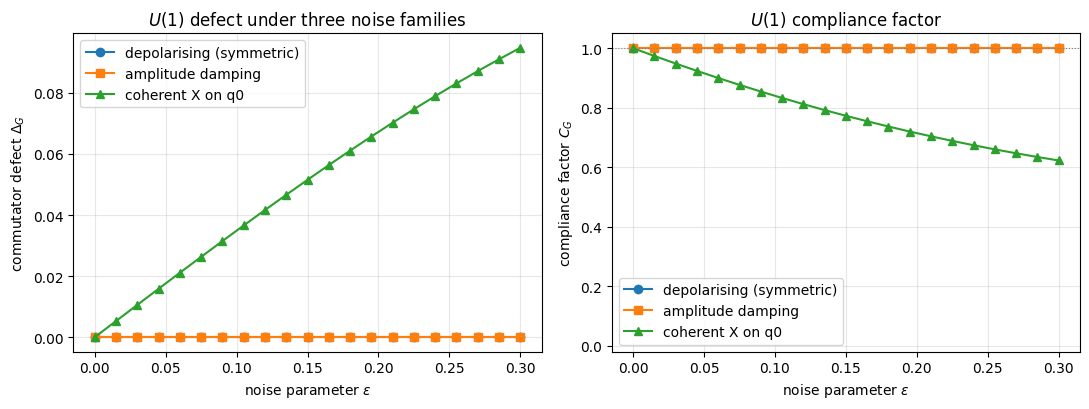

In [ ]:
# ---- Paper Figure 2: U(1) phase-symmetry sweep ----
fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.7))

axA.plot(eps_grid, df_sweep_u1["delta_depolarising"],  "o-", label="depolarising (symmetric)")
axA.plot(eps_grid, df_sweep_u1["delta_amp_damp"],      "s-", label="amplitude damping")
axA.plot(eps_grid, df_sweep_u1["delta_coherent_X_q0"], "^-", label=r"coherent $X$ on q0")
axA.set_xlabel(r"noise parameter $\varepsilon$")
axA.set_ylabel(r"commutator defect $\Delta_G$")
axA.legend(loc="upper left", framealpha=0.9)
axA.grid(alpha=0.3)
axA.text(-0.13, 1.06, "A", transform=axA.transAxes,
         fontsize=11, fontweight="bold", va="top", ha="left")

axB.plot(eps_grid, df_sweep_u1["C_G_depolarising"],    "o-", label="depolarising (symmetric)")
axB.plot(eps_grid, df_sweep_u1["C_G_amp_damp"],        "s-", label="amplitude damping")
axB.plot(eps_grid, df_sweep_u1["C_G_coherent_X_q0"],   "^-", label=r"coherent $X$ on q0")
axB.set_xlabel(r"noise parameter $\varepsilon$")
axB.set_ylabel(r"compliance score $C_G$")
axB.set_ylim([-0.02, 1.05])
axB.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
axB.legend(loc="lower left", framealpha=0.9)
axB.grid(alpha=0.3)
axB.text(-0.13, 1.06, "B", transform=axB.transAxes,
         fontsize=11, fontweight="bold", va="top", ha="left")

plt.tight_layout()
save_paper_figure(fig, "Figure2")
plt.show()


## Section 4: $SU(2)$ experiments

In [ ]:
# Group elements and identity-channel baseline for SU(2).
n_su2 = CFG["n_qubits_su2"]
d_su2 = 2 ** n_su2

rng_su2 = np.random.default_rng(CFG["rng_seed"] + 1)
su2_grp = su2_collective_supers(n_su2, CFG["n_su2_samples"], rng_su2)
Phi_id_su2 = np.eye(d_su2 * d_su2, dtype=complex)

print(f"SU(2) on {n_su2} qubits (spin-1/2 collective), "
      f"{len(su2_grp)} Haar samples. Liouville dim = {d_su2**2}.")

SU(2) on 2 qubits (spin-1/2 collective), 50 Haar samples. Liouville dim = 16.


In [ ]:
# ---- Sanity-control results for SU(2) ----
sanity_su2 = []

delta = Delta_G(Phi_id_su2, su2_grp)
sanity_su2.append(("identity", delta, C_G_from_delta(delta)))

rng = np.random.default_rng(CFG["rng_seed"] + 2)
deltas_rand_su2 = []
for s in range(CFG["n_random_seeds"]):
    U_rand = unitary_group.rvs(d_su2, random_state=rng)
    Phi_rand = sup_unitary(U_rand)
    deltas_rand_su2.append(Delta_G(Phi_rand, su2_grp))
sanity_su2.append(("haar_random_mean",
                   float(np.mean(deltas_rand_su2)),
                   float(np.exp(-CFG["gamma"] * np.mean(deltas_rand_su2)))))

Phi_d = sup_local_channel(kraus_depol_1q(0.3), n_su2, sites="all")
delta = Delta_G(Phi_d, su2_grp)
sanity_su2.append(("depolarising_p=0.3", delta, C_G_from_delta(delta)))

Phi_a = sup_local_channel(kraus_amp_damp_1q(0.3), n_su2, sites="all")
delta = Delta_G(Phi_a, su2_grp)
sanity_su2.append(("amp_damp_eps=0.3", delta, C_G_from_delta(delta)))

Phi_c = sup_local_channel(kraus_coherent_x_1q(0.3), n_su2, sites="first")
delta = Delta_G(Phi_c, su2_grp)
sanity_su2.append(("coherent_X_q0_eps=0.3", delta, C_G_from_delta(delta)))

df_sanity_su2 = pd.DataFrame(sanity_su2, columns=["channel", "Delta_G", "C_G"])
df_sanity_su2

,channel,Delta_G,C_G
0,identity,0.000000e+00,1.000000
1,haar_random_mean,1.646248e-01,0.439058
2,depolarising_p=0.3,1.590134e-17,1.000000
3,amp_damp_eps=0.3,4.350694e-02,0.804500
4,coherent_X_q0_eps=0.3,1.010927e-01,0.603226


In [ ]:
# ---- SU(2) noise sweeps ----
sweep_su2 = {"depolarising": [], "amp_damp": [], "coherent_X_q0": []}

for eps in eps_grid:
    Phi = sup_local_channel(kraus_depol_1q(eps), n_su2, sites="all")
    sweep_su2["depolarising"].append(Delta_G(Phi, su2_grp))

    Phi = sup_local_channel(kraus_amp_damp_1q(eps), n_su2, sites="all")
    sweep_su2["amp_damp"].append(Delta_G(Phi, su2_grp))

    Phi = sup_local_channel(kraus_coherent_x_1q(eps), n_su2, sites="first")
    sweep_su2["coherent_X_q0"].append(Delta_G(Phi, su2_grp))

df_sweep_su2 = pd.DataFrame({
    "eps": eps_grid,
    "delta_depolarising":   sweep_su2["depolarising"],
    "delta_amp_damp":       sweep_su2["amp_damp"],
    "delta_coherent_X_q0":  sweep_su2["coherent_X_q0"],
    "C_G_depolarising":     [C_G_from_delta(d) for d in sweep_su2["depolarising"]],
    "C_G_amp_damp":         [C_G_from_delta(d) for d in sweep_su2["amp_damp"]],
    "C_G_coherent_X_q0":    [C_G_from_delta(d) for d in sweep_su2["coherent_X_q0"]],
})
df_sweep_su2.head()

,eps,delta_depolarising,delta_amp_damp,delta_coherent_X_q0,C_G_depolarising,C_G_amp_damp,C_G_coherent_X_q0
0,0.000,0.000000e+00,0.000000,0.000000,1.0,1.000000,1.000000
1,0.015,1.192282e-17,0.001936,0.005611,1.0,0.990367,0.972335
2,0.030,9.773070e-18,0.003899,0.011213,1.0,0.980696,0.945476
3,0.045,1.174115e-17,0.005888,0.016798,1.0,0.970991,0.919441
4,0.060,1.293023e-17,0.007903,0.022356,1.0,0.961255,0.894239


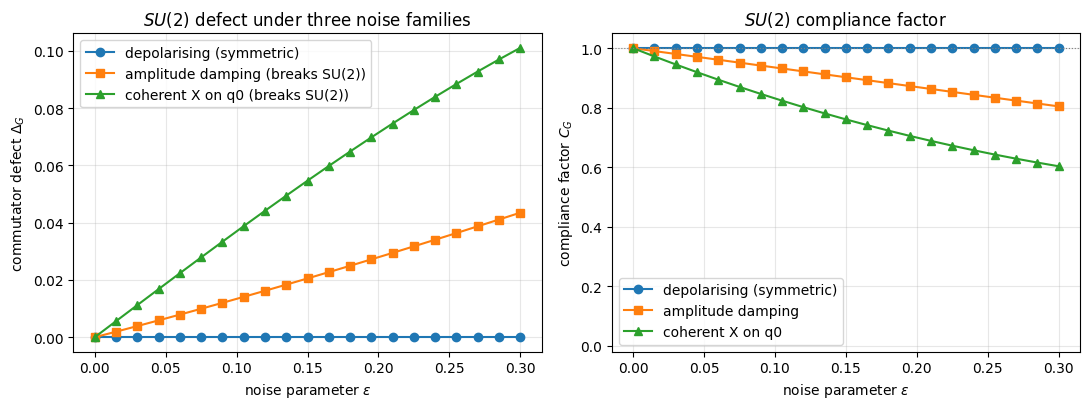

In [ ]:
# ---- Paper Figure 3: SU(2) rotation-symmetry sweep ----
fig, (axA, axB) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 2.7))

axA.plot(eps_grid, df_sweep_su2["delta_depolarising"],  "o-", label="depolarising (symmetric)")
axA.plot(eps_grid, df_sweep_su2["delta_amp_damp"],      "s-", label=r"amplitude damping (breaks $SU(2)$)")
axA.plot(eps_grid, df_sweep_su2["delta_coherent_X_q0"], "^-", label=r"coherent $X$ on q0 (breaks $SU(2)$)")
axA.set_xlabel(r"noise parameter $\varepsilon$")
axA.set_ylabel(r"commutator defect $\Delta_G$")
axA.legend(loc="upper left", framealpha=0.9, fontsize=7.5)
axA.grid(alpha=0.3)
axA.text(-0.13, 1.06, "A", transform=axA.transAxes,
         fontsize=11, fontweight="bold", va="top", ha="left")

axB.plot(eps_grid, df_sweep_su2["C_G_depolarising"],    "o-", label="depolarising (symmetric)")
axB.plot(eps_grid, df_sweep_su2["C_G_amp_damp"],        "s-", label="amplitude damping")
axB.plot(eps_grid, df_sweep_su2["C_G_coherent_X_q0"],   "^-", label=r"coherent $X$ on q0")
axB.set_xlabel(r"noise parameter $\varepsilon$")
axB.set_ylabel(r"compliance score $C_G$")
axB.set_ylim([-0.02, 1.05])
axB.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
axB.legend(loc="lower left", framealpha=0.9)
axB.grid(alpha=0.3)
axB.text(-0.13, 1.06, "B", transform=axB.transAxes,
         fontsize=11, fontweight="bold", va="top", ha="left")

plt.tight_layout()
save_paper_figure(fig, "Figure3")
plt.show()


## Section 5: robustness diagnostics

Nine targeted checks (R1–R9) addressing the questions a reviewer at PLOS One
is most likely to press on. The set is deliberately small but covers:

* exactness of the lemma to machine precision (R1–R3),
* per-seed robustness of the breaking baseline (R4–R5),
* numerical stability of the $SU(2)$ Haar estimator across multiple test
  channels (R6),
* dimension-invariant separation at $n=3$ qubits (R7),
* validity of the underlying Kraus channels (R8),
* invariance under a different norm choice (R9).

**Manuscript-relevant note from R7.** Under the Frobenius normalisation used
here, the maximum value of $\Delta_G$ for unitary channels is bounded by
$1/d$, where $d$ is the system dimension. So absolute breaking magnitudes
shrink with system size even when discrimination remains perfect. The paper
will need to flag this as a calibration point rather than a flaw: $\gamma$
should be tuned to system size if a fixed $C_G$ scale is desired across $n$,
and the lemma itself is dimension-invariant (it depends only on whether
$\Delta_G$ is exactly zero, not on its absolute magnitude).

Each check produces a boolean pass flag; the final cell of this section
collects them into a robustness verdict.

In [ ]:
# ---- R1: Delta_G machine-zero floor for every equivariant case ----
print("R1: Delta_G floor for equivariant cases (must be < {:.0e})".format(CFG["machine_zero"]))
print()
floor_cases = [
    ("U(1) identity",            df_sanity_u1,  "identity"),
    ("U(1) depol p=0.3",         df_sanity_u1,  "depolarising_p=0.3"),
    ("U(1) amp damp eps=0.3",    df_sanity_u1,  "amp_damp_eps=0.3"),
    ("SU(2) identity",           df_sanity_su2, "identity"),
    ("SU(2) depol p=0.3",        df_sanity_su2, "depolarising_p=0.3"),
]
floor_results = []
for label, df, key in floor_cases:
    delta = float(df.loc[df["channel"] == key, "Delta_G"].iloc[0])
    floor_results.append((label, delta, delta < CFG["machine_zero"]))
    print(f"  {label:30s}: Delta_G = {delta:.3e}")
R1_pass = all(r[2] for r in floor_results)
print(f"\n  R1 verdict: {'PASS' if R1_pass else 'FAIL'}")

R1: Delta_G floor for equivariant cases (must be < 1e-10)

  U(1) identity                 : Delta_G = 0.000e+00
  U(1) depol p=0.3              : Delta_G = 2.286e-18
  U(1) amp damp eps=0.3         : Delta_G = 2.121e-18
  SU(2) identity                : Delta_G = 0.000e+00
  SU(2) depol p=0.3             : Delta_G = 1.590e-17

  R1 verdict: PASS


In [ ]:
# ---- R2: non-trivial U(1)-equivariant unitary, not just identity ----

def random_u1_equivariant_unitary(n_qubits, rng):
    '''A U(1)-equivariant unitary built by mixing within charge sectors and
    assigning a random phase to one-dimensional sectors. Non-trivial in the
    sense that it is not proportional to the identity in any sector.'''
    N = n_total_op(n_qubits)
    eigs = np.diag(N).real.astype(int)
    V = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
    for q in np.unique(eigs):
        idx = np.where(eigs == q)[0]
        if len(idx) == 1:
            V[idx[0], idx[0]] = np.exp(2j * np.pi * rng.uniform())
        else:
            U_sec = unitary_group.rvs(len(idx), random_state=rng)
            for i_local, ii in enumerate(idx):
                for j_local, jj in enumerate(idx):
                    V[ii, jj] = U_sec[i_local, j_local]
    return V


rng_R2 = np.random.default_rng(CFG["rng_seed"] + 10)
R2_deltas = []
for trial in range(5):
    V = random_u1_equivariant_unitary(n_u1, rng_R2)
    delta = Delta_G(sup_unitary(V), u1_grp)
    R2_deltas.append(delta)
print(f"R2: U(1) non-trivial equivariant unitaries, 5 random instances")
for i, d in enumerate(R2_deltas):
    print(f"  trial {i}: Delta_G = {d:.3e}")
R2_pass = all(d < CFG["machine_zero"] for d in R2_deltas)
print(f"\n  R2 verdict: {'PASS' if R2_pass else 'FAIL'}")

R2: U(1) non-trivial equivariant unitaries, 5 random instances
  trial 0: Delta_G = 3.563e-18
  trial 1: Delta_G = 4.484e-18
  trial 2: Delta_G = 3.624e-18
  trial 3: Delta_G = 4.015e-18
  trial 4: Delta_G = 3.748e-18

  R2 verdict: PASS


In [ ]:
# ---- R3: non-trivial SU(2)-equivariant unitary ----

def random_su2_equivariant_unitary_2q(rng):
    '''On 2 qubits the collective SU(2) representation decomposes as
    triplet (j=1) + singlet (j=0). An equivariant unitary is a phase on
    each block (Schur). Non-trivial whenever the two phases differ.'''
    psi_S = np.array([0, 1, -1, 0], dtype=complex) / np.sqrt(2)
    psi_T = [
        np.array([1, 0, 0, 0], dtype=complex),
        np.array([0, 1, 1, 0], dtype=complex) / np.sqrt(2),
        np.array([0, 0, 0, 1], dtype=complex),
    ]
    P_S = np.outer(psi_S, psi_S.conj())
    P_T = sum(np.outer(psi, psi.conj()) for psi in psi_T)
    phi_S = 2 * np.pi * rng.uniform()
    phi_T = 2 * np.pi * rng.uniform()
    return np.exp(1j * phi_T) * P_T + np.exp(1j * phi_S) * P_S


rng_R3 = np.random.default_rng(CFG["rng_seed"] + 11)
R3_deltas = []
for trial in range(5):
    V = random_su2_equivariant_unitary_2q(rng_R3)
    delta = Delta_G(sup_unitary(V), su2_grp)
    R3_deltas.append(delta)
print(f"R3: SU(2) non-trivial equivariant unitaries, 5 random instances")
for i, d in enumerate(R3_deltas):
    print(f"  trial {i}: Delta_G = {d:.3e}")
R3_pass = all(d < CFG["machine_zero"] for d in R3_deltas)
print(f"\n  R3 verdict: {'PASS' if R3_pass else 'FAIL'}")

R3: SU(2) non-trivial equivariant unitaries, 5 random instances
  trial 0: Delta_G = 2.896e-17
  trial 1: Delta_G = 2.573e-17
  trial 2: Delta_G = 2.593e-17
  trial 3: Delta_G = 2.917e-17
  trial 4: Delta_G = 2.383e-17

  R3 verdict: PASS


In [ ]:
# ---- R4 / R5: per-seed Haar baseline statistics ----
cgs_u1_seeds  = np.exp(-CFG["gamma"] * np.array(deltas_rand_u1))
cgs_su2_seeds = np.exp(-CFG["gamma"] * np.array(deltas_rand_su2))

print("R4: U(1) Haar baseline, per-seed C_G")
print(f"  values: " + ", ".join(f"{c:.3f}" for c in cgs_u1_seeds))
print(f"  min={cgs_u1_seeds.min():.4f}  max={cgs_u1_seeds.max():.4f}  "
      f"mean={cgs_u1_seeds.mean():.4f}  std={cgs_u1_seeds.std():.4f}")
R4_pass = bool(cgs_u1_seeds.max() <= 0.6)
print(f"  R4 verdict: {'PASS' if R4_pass else 'FAIL'} (worst seed C_G <= 0.60)")

print()
print("R5: SU(2) Haar baseline, per-seed C_G")
print(f"  values: " + ", ".join(f"{c:.3f}" for c in cgs_su2_seeds))
print(f"  min={cgs_su2_seeds.min():.4f}  max={cgs_su2_seeds.max():.4f}  "
      f"mean={cgs_su2_seeds.mean():.4f}  std={cgs_su2_seeds.std():.4f}")
R5_pass = bool(cgs_su2_seeds.max() <= 0.6)
print(f"  R5 verdict: {'PASS' if R5_pass else 'FAIL'} (worst seed C_G <= 0.60)")

R4: U(1) Haar baseline, per-seed C_G
  values: 0.508, 0.479, 0.502, 0.489, 0.500, 0.496, 0.494, 0.492, 0.498, 0.481
  min=0.4791  max=0.5077  mean=0.4939  std=0.0085
  R4 verdict: PASS (worst seed C_G <= 0.60)

R5: SU(2) Haar baseline, per-seed C_G
  values: 0.439, 0.435, 0.437, 0.436, 0.435, 0.437, 0.439, 0.446, 0.437, 0.449
  min=0.4352  max=0.4489  mean=0.4391  std=0.0045
  R5 verdict: PASS (worst seed C_G <= 0.60)


In [ ]:
# ---- R6: SU(2) Haar sampling stability across multiple test channels ----

R6_test_channels = {
    "identity":          np.eye(d_su2 * d_su2, dtype=complex),
    "amp_damp_eps=0.2":  sup_local_channel(kraus_amp_damp_1q(0.2), n_su2, "all"),
    "coherent_X_eps=0.2": sup_local_channel(kraus_coherent_x_1q(0.2), n_su2, "first"),
    "depol_p=0.2":       sup_local_channel(kraus_depol_1q(0.2), n_su2, "all"),
}
sample_sizes = [10, 25, 50, 100]
n_trials = 6
rng_R6 = np.random.default_rng(CFG["rng_seed"] + 50)

stab_rows = []
for label, Phi in R6_test_channels.items():
    for nsmp in sample_sizes:
        deltas = []
        for trial in range(n_trials):
            seed = int(rng_R6.integers(1 << 30))
            grp = su2_collective_supers(n_su2, nsmp, np.random.default_rng(seed))
            deltas.append(Delta_G(Phi, grp))
        stab_rows.append([label, nsmp, float(np.mean(deltas)), float(np.std(deltas))])

df_stab = pd.DataFrame(stab_rows, columns=["channel", "n_samples", "mean_Delta", "std_Delta"])

# Relative std at n=50, restricted to channels with non-trivial defect
fifty = df_stab[df_stab["n_samples"] == 50]
relstds = []
for _, row in fifty.iterrows():
    if row["mean_Delta"] > 1e-6:
        relstds.append(row["std_Delta"] / row["mean_Delta"])

R6_max_relstd = float(max(relstds)) if relstds else 0.0
R6_pass = R6_max_relstd < CFG["relstd_threshold"]

print("R6: SU(2) sampling stability, mean Delta_G across 6 trials per (channel, n)")
print(df_stab.pivot(index="n_samples", columns="channel", values="mean_Delta").round(5))
print(f"\n  Max relative std at n=50 (non-equivariant channels): {R6_max_relstd:.4f}")
print(f"  R6 verdict: {'PASS' if R6_pass else 'FAIL'} "
      f"(rel std < {CFG['relstd_threshold']*100:.0f}% at n=50)")

R6: SU(2) sampling stability, mean Delta_G across 6 trials per (channel, n)
channel    amp_damp_eps=0.2  coherent_X_eps=0.2  depol_p=0.2  identity
n_samples                                                             
10                  0.02784             0.07219          0.0       0.0
25                  0.02772             0.06889          0.0       0.0
50                  0.02783             0.06974          0.0       0.0
100                 0.02811             0.07185          0.0       0.0

  Max relative std at n=50 (non-equivariant channels): 0.0327
  R6 verdict: PASS (rel std < 5% at n=50)


In [ ]:
# ---- Paper Figure 6: SU(2) Haar sampling stability ----
channel_order = [
    "identity",
    "depol_p=0.2",
    "amp_damp_eps=0.2",
    "coherent_X_eps=0.2",
]
channel_label = {
    "identity":            "identity (equivariant)",
    "depol_p=0.2":         r"depolarising $p{=}0.2$ (equivariant)",
    "amp_damp_eps=0.2":    r"amplitude damping $\varepsilon{=}0.2$",
    "coherent_X_eps=0.2":  r"coherent $X$ on q0, $\varepsilon{=}0.2$",
}
channel_marker = {
    "identity":            "o",
    "depol_p=0.2":         "D",
    "amp_damp_eps=0.2":    "s",
    "coherent_X_eps=0.2":  "^",
}

fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.6))

for ch in channel_order:
    if ch not in df_stab["channel"].values:
        continue
    d = df_stab[df_stab["channel"] == ch].sort_values("n_samples")
    ax.errorbar(
        d["n_samples"], d["mean_Delta"], yerr=d["std_Delta"],
        marker=channel_marker[ch], capsize=2.5, linewidth=1.2,
        markersize=4.5, label=channel_label[ch],
    )

ax.set_xscale("log")
ax.set_xticks([10, 25, 50, 100])
ax.set_xticklabels(["10", "25", "50", "100"])
ax.set_xlabel(r"Haar sample count $|S|$")
ax.set_ylabel(r"mean $\Delta_G$ ($\pm 1\sigma$)")
ax.set_ylim(-0.005, 0.115)
ax.legend(loc="upper left", framealpha=0.95, fontsize=6.5,
          borderpad=0.3, labelspacing=0.25, handlelength=1.5,
          handletextpad=0.4)
ax.grid(alpha=0.3)
plt.tight_layout()
save_paper_figure(fig, "Figure6")
plt.show()


In [ ]:
# ---- R7: dimension-invariant separation at n=3 qubits ----
#
# The Frobenius-normalised Delta_G has the property that for unitary channels,
# its maximum value scales like 1/d, so absolute breaking magnitudes shrink with
# system size even when discrimination remains perfect. R7 therefore tests the
# *dimension-invariant* claim that matters: equivariant cases sit at the
# machine-zero floor while non-equivariant cases sit clearly above it, with
# orders-of-magnitude separation. This separation is what the manuscript's
# lemma actually requires.

n_u1_3 = CFG["n_qubits_u1_R7"]
d_u1_3 = 2 ** n_u1_3
u1_grp_3, _ = u1_supers(n_u1_3, CFG["n_u1_samples"])
Phi_id_3 = np.eye(d_u1_3 * d_u1_3, dtype=complex)

# Thresholds for R7
floor_n3   = 1e-10   # equivariant cases must be below this
signal_n3  = 1e-3    # non-equivariant cases must be above this

n3_rows = []

# Equivariant cases at n=3
n3_rows.append(("identity",
                Delta_G(Phi_id_3, u1_grp_3),
                "equivariant"))

Phi_d3 = sup_local_channel(kraus_depol_1q(0.3), n_u1_3, "all")
n3_rows.append(("depol_p=0.3",
                Delta_G(Phi_d3, u1_grp_3),
                "equivariant"))

Phi_a3 = sup_local_channel(kraus_amp_damp_1q(0.3), n_u1_3, "all")
n3_rows.append(("amp_damp_eps=0.3",
                Delta_G(Phi_a3, u1_grp_3),
                "equivariant"))

# Non-equivariant cases at n=3
Phi_c3 = sup_local_channel(kraus_coherent_x_1q(0.3), n_u1_3, "first")
n3_rows.append(("coherent_X_eps=0.3",
                Delta_G(Phi_c3, u1_grp_3),
                "non-equivariant"))

rng_R7 = np.random.default_rng(CFG["rng_seed"] + 60)
deltas_haar_n3 = [Delta_G(sup_unitary(unitary_group.rvs(d_u1_3, random_state=rng_R7)),
                          u1_grp_3) for _ in range(CFG["n_random_seeds"])]
n3_rows.append(("haar_random_mean",
                float(np.mean(deltas_haar_n3)),
                "non-equivariant"))

# Build dataframe with pass/fail per row
def r7_check(delta, kind):
    if kind == "equivariant":
        return delta < floor_n3
    return delta > signal_n3

df_n3 = pd.DataFrame(
    [(label, delta, kind,
      f"< {floor_n3:.0e}" if kind == "equivariant" else f"> {signal_n3:.0e}",
      "PASS" if r7_check(delta, kind) else "FAIL")
     for label, delta, kind in n3_rows],
    columns=["channel", "Delta_G", "type", "rule", "result"],
)

R7_pass = bool((df_n3["result"] == "PASS").all())

# Quantify the separation explicitly
max_eq    = df_n3.loc[df_n3["type"] == "equivariant",     "Delta_G"].max()
min_break = df_n3.loc[df_n3["type"] == "non-equivariant", "Delta_G"].min()
sep_orders = float(np.log10(max(min_break, 1e-300)) - np.log10(max(max_eq, 1e-300)))

print(f"R7: dimension-invariant separation at n={n_u1_3} qubits")
print(df_n3.to_string(index=False))
print()
print(f"  max  equivariant   Delta_G: {max_eq:.3e}")
print(f"  min  non-equiv.    Delta_G: {min_break:.3e}")
print(f"  separation: {sep_orders:.1f} orders of magnitude")
print(f"\n  R7 verdict: {'PASS' if R7_pass else 'FAIL'} "
      f"(equivariant < {floor_n3:.0e}, non-equivariant > {signal_n3:.0e})")

R7: dimension-invariant separation at n=3 qubits
           channel      Delta_G            type    rule result
          identity 0.000000e+00     equivariant < 1e-10   PASS
       depol_p=0.3 3.483373e-18     equivariant < 1e-10   PASS
  amp_damp_eps=0.3 4.239087e-18     equivariant < 1e-10   PASS
coherent_X_eps=0.3 4.737588e-02 non-equivariant > 1e-03   PASS
  haar_random_mean 7.376394e-02 non-equivariant > 1e-03   PASS

  max  equivariant   Delta_G: 4.239e-18
  min  non-equiv.    Delta_G: 4.738e-02
  separation: 16.0 orders of magnitude

  R7 verdict: PASS (equivariant < 1e-10, non-equivariant > 1e-03)


In [ ]:
# ---- R8: CPTP validation of every Kraus channel used in the pilot ----

cptp_checks = []
eps_test = [0.05, 0.1, 0.2, 0.3]

for eps in eps_test:
    cptp_checks.append((f"depol_1q(p={eps})",      kraus_is_tp(kraus_depol_1q(eps))))
    cptp_checks.append((f"amp_damp_1q(eps={eps})", kraus_is_tp(kraus_amp_damp_1q(eps))))
    cptp_checks.append((f"coherent_X_1q(eps={eps})", kraus_is_tp(kraus_coherent_x_1q(eps))))

# Multi-qubit expansion preserves trace-preservation
for eps in eps_test:
    for n_q in [2, 3]:
        kfull = expand_kraus_local(kraus_depol_1q(eps), n_q, "all")
        cptp_checks.append((f"depol_n={n_q}(p={eps})", kraus_is_tp(kfull)))
        kfull = expand_kraus_local(kraus_amp_damp_1q(eps), n_q, "all")
        cptp_checks.append((f"amp_damp_n={n_q}(eps={eps})", kraus_is_tp(kfull)))
        kfull = expand_kraus_local(kraus_coherent_x_1q(eps), n_q, "first")
        cptp_checks.append((f"coh_X_q0_n={n_q}(eps={eps})", kraus_is_tp(kfull)))

R8_pass = all(c[1] for c in cptp_checks)
print(f"R8: CPTP validation of {len(cptp_checks)} Kraus channels")
print(f"  All trace-preserving (atol={CFG['tp_atol']:.0e}): {R8_pass}")
if not R8_pass:
    for label, ok in cptp_checks:
        if not ok:
            print(f"    FAIL: {label}")
print(f"\n  R8 verdict: {'PASS' if R8_pass else 'FAIL'}")

R8: CPTP validation of 36 Kraus channels
  All trace-preserving (atol=1e-10): True

  R8 verdict: PASS


In [ ]:
# ---- R9: norm choice (operator vs Frobenius) preserves qualitative ordering ----

# Compute Delta_G with operator norm at eps_max for each SU(2) noise family
op_eps = CFG["eps_max"]

op_results = {}
for label, kraus_fn, sites in [
    ("depolarising",  lambda: kraus_depol_1q(op_eps),       "all"),
    ("amp_damp",      lambda: kraus_amp_damp_1q(op_eps),    "all"),
    ("coherent_X_q0", lambda: kraus_coherent_x_1q(op_eps), "first"),
]:
    Phi = sup_local_channel(kraus_fn(), n_su2, sites)
    op_results[label] = Delta_G(Phi, su2_grp, defect_fn=commutator_defect_op)

fro_at_max = {
    "depolarising":  float(df_sweep_su2["delta_depolarising"].iloc[-1]),
    "amp_damp":      float(df_sweep_su2["delta_amp_damp"].iloc[-1]),
    "coherent_X_q0": float(df_sweep_su2["delta_coherent_X_q0"].iloc[-1]),
}

fro_order = sorted(fro_at_max, key=fro_at_max.get)
op_order  = sorted(op_results,  key=op_results.get)
R9_pass = (fro_order == op_order)

print(f"R9: norm-choice qualitative invariance at eps={op_eps}")
print()
print("  Frobenius norm Delta_G:")
for k in fro_order:
    print(f"    {k:18s}: {fro_at_max[k]:.4f}")
print("  Operator  norm Delta_G:")
for k in op_order:
    print(f"    {k:18s}: {op_results[k]:.4f}")
print(f"\n  Frobenius ordering: {fro_order}")
print(f"  Operator  ordering: {op_order}")
print(f"\n  R9 verdict: {'PASS' if R9_pass else 'FAIL'} (orderings match)")

R9: norm-choice qualitative invariance at eps=0.3

  Frobenius norm Delta_G:
    depolarising      : 0.0000
    amp_damp          : 0.0435
    coherent_X_q0     : 0.1011
  Operator  norm Delta_G:
    depolarising      : 0.0000
    amp_damp          : 0.2501
    coherent_X_q0     : 0.5719

  Frobenius ordering: ['depolarising', 'amp_damp', 'coherent_X_q0']
  Operator  ordering: ['depolarising', 'amp_damp', 'coherent_X_q0']

  R9 verdict: PASS (orderings match)


In [ ]:
# ---- Robustness verdict ----
R_results = [
    ("R1", "Delta_G < 1e-10 on every equivariant case",         R1_pass),
    ("R2", "Non-trivial U(1)-equivariant unitary at floor",     R2_pass),
    ("R3", "Non-trivial SU(2)-equivariant unitary at floor",    R3_pass),
    ("R4", "U(1) Haar baseline robust across all seeds",        R4_pass),
    ("R5", "SU(2) Haar baseline robust across all seeds",       R5_pass),
    ("R6", "SU(2) sampling stability < 5% rel std at n=50",     R6_pass),
    ("R7", "Dimension-invariant separation at n=3 qubits",     R7_pass),
    ("R8", "All Kraus channels CPTP to 1e-10",                  R8_pass),
    ("R9", "Operator-norm ordering matches Frobenius",          R9_pass),
]
df_R = pd.DataFrame(
    [(name, desc, "PASS" if ok else "FAIL") for name, desc, ok in R_results],
    columns=["check", "description", "result"],
)
n_R_pass = sum(1 for _, _, ok in R_results if ok)
print(df_R.to_string(index=False))
print(f"\nRobustness summary: {n_R_pass} / {len(R_results)} passed.")

check                                    description result
   R1      Delta_G < 1e-10 on every equivariant case   PASS
   R2  Non-trivial U(1)-equivariant unitary at floor   PASS
   R3 Non-trivial SU(2)-equivariant unitary at floor   PASS
   R4     U(1) Haar baseline robust across all seeds   PASS
   R5    SU(2) Haar baseline robust across all seeds   PASS
   R6  SU(2) sampling stability < 5% rel std at n=50   PASS
   R7   Dimension-invariant separation at n=3 qubits   PASS
   R8               All Kraus channels CPTP to 1e-10   PASS
   R9       Operator-norm ordering matches Frobenius   PASS

Robustness summary: 9 / 9 passed.


## Section 6: mixed-noise diagnostic

Holds depolarising fixed at $p = 0.1$ (symmetric), then ramps coherent $X$ on
qubit 0. Tests whether $C_G$ correctly attributes the symmetry breaking to the
$X$ component rather than to the symmetric depolarising background.

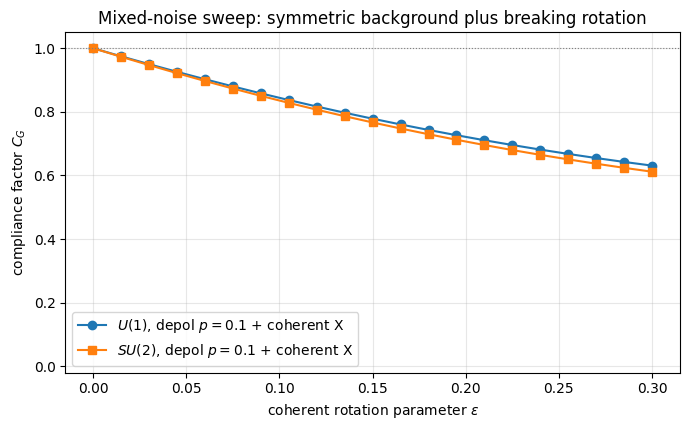

,eps,delta_u1,delta_su2,C_G_u1,C_G_su2
0,0.000,5.073999e-19,1.558412e-17,1.000000,1.000000
1,0.015,5.148183e-03,5.453414e-03,0.974588,0.973101
2,0.030,1.028779e-02,1.089828e-02,0.949862,0.946967
3,0.045,1.541026e-02,1.632608e-02,0.925842,0.921613
4,0.060,2.050709e-02,2.172833e-02,0.902546,0.897052


In [ ]:
# ---- Mixed-noise sweep on U(1) and SU(2) ----
mix_u1_delta = []
for eps in eps_grid:
    Phi_d = sup_local_channel(kraus_depol_1q(0.1), n_u1, sites="all")
    Phi_x = sup_local_channel(kraus_coherent_x_1q(eps), n_u1, sites="first")
    Phi_mixed = Phi_x @ Phi_d  # depolarise then coherent rotation
    mix_u1_delta.append(Delta_G(Phi_mixed, u1_grp))

mix_su2_delta = []
for eps in eps_grid:
    Phi_d = sup_local_channel(kraus_depol_1q(0.1), n_su2, sites="all")
    Phi_x = sup_local_channel(kraus_coherent_x_1q(eps), n_su2, sites="first")
    Phi_mixed = Phi_x @ Phi_d
    mix_su2_delta.append(Delta_G(Phi_mixed, su2_grp))

df_mixed = pd.DataFrame({
    "eps":       eps_grid,
    "delta_u1":  mix_u1_delta,
    "delta_su2": mix_su2_delta,
    "C_G_u1":    [C_G_from_delta(d) for d in mix_u1_delta],
    "C_G_su2":   [C_G_from_delta(d) for d in mix_su2_delta],
})
df_mixed.head()


In [ ]:
# ---- Paper Figure 4: mixed-noise sweep ----
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.5))
ax.plot(eps_grid, df_mixed["C_G_u1"],  "o-", label=r"$U(1)$, depol $p=0.1$ + coherent $X$")
ax.plot(eps_grid, df_mixed["C_G_su2"], "s-", label=r"$SU(2)$, depol $p=0.1$ + coherent $X$")
ax.set_xlabel(r"coherent rotation parameter $\varepsilon$")
ax.set_ylabel(r"compliance score $C_G$")
ax.set_ylim([-0.02, 1.05])
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
ax.legend(loc="lower left", framealpha=0.9, fontsize=7.5)
ax.grid(alpha=0.3)
plt.tight_layout()
save_paper_figure(fig, "Figure4")
plt.show()


## Section 7: pre-registered verdict

In [ ]:
# ---- Evaluate the V1-V10 diagnostic checks against thresholds ----

def cg_of(label, df):
    return float(df.loc[df["channel"] == label, "C_G"].iloc[0])

V = {}
V["V1"]  = ("U(1) identity",                cg_of("identity", df_sanity_u1),                ">= 0.99")
V["V2"]  = ("U(1) Haar random",             cg_of("haar_random_mean", df_sanity_u1),        "<= 0.60")
V["V3"]  = ("U(1) depol p=0.3",             cg_of("depolarising_p=0.3", df_sanity_u1),      ">= 0.99")
V["V4"]  = ("U(1) amp damp eps=0.3",        cg_of("amp_damp_eps=0.3", df_sanity_u1),        ">= 0.99")
V["V5"]  = ("U(1) coherent X eps=0.3",      cg_of("coherent_X_q0_eps=0.3", df_sanity_u1),   "<= 0.70")
V["V6"]  = ("SU(2) identity",               cg_of("identity", df_sanity_su2),               ">= 0.99")
V["V7"]  = ("SU(2) Haar random",            cg_of("haar_random_mean", df_sanity_su2),       "<= 0.60")
V["V8"]  = ("SU(2) depol p=0.3",            cg_of("depolarising_p=0.3", df_sanity_su2),     ">= 0.99")
V["V9"]  = ("SU(2) amp damp eps=0.3",       cg_of("amp_damp_eps=0.3", df_sanity_su2),       "<= 0.85")
V["V10"] = ("SU(2) coherent X eps=0.3",     cg_of("coherent_X_q0_eps=0.3", df_sanity_su2),  "<= 0.70")


def check(value, rule):
    op, thr = rule.split()
    thr = float(thr)
    return (value >= thr) if op == ">=" else (value <= thr)


v_rows = []
for name, (label, value, rule) in V.items():
    passed = check(value, rule)
    v_rows.append([name, label, f"{value:.4f}", rule, "PASS" if passed else "FAIL"])
df_verdict = pd.DataFrame(v_rows, columns=["check", "setting", "C_G", "required", "result"])
df_verdict

,check,setting,C_G,required,result
0,V1,U(1) identity,1.0000,>= 0.99,PASS
1,V2,U(1) Haar random,0.4938,<= 0.60,PASS
2,V3,U(1) depol p=0.3,1.0000,>= 0.99,PASS
3,V4,U(1) amp damp eps=0.3,1.0000,>= 0.99,PASS
4,V5,U(1) coherent X eps=0.3,0.6227,<= 0.70,PASS
5,V6,SU(2) identity,1.0000,>= 0.99,PASS
6,V7,SU(2) Haar random,0.4391,<= 0.60,PASS
7,V8,SU(2) depol p=0.3,1.0000,>= 0.99,PASS
8,V9,SU(2) amp damp eps=0.3,0.8045,<= 0.85,PASS
9,V10,SU(2) coherent X eps=0.3,0.6032,<= 0.70,PASS


In [ ]:
# ---- Final verdict: combine V1-V10 with R1-R9 ----
all_pass_main   = all(row[-1] == "PASS" for row in v_rows)
all_pass_robust = all(ok for _, _, ok in R_results)
n_pass_V        = sum(1 for row in v_rows if row[-1] == "PASS")
n_pass_R        = sum(1 for _, _, ok in R_results if ok)

print(f"Diagnostic correctness: {n_pass_V} / 10")
print(f"Robustness checks:      {n_pass_R} / {len(R_results)}")
print()

if all_pass_main and all_pass_robust:
    print("VERDICT: GO. Diagnostic correctness and robustness both confirmed. "
          "The PLOS One channel-level C_G manuscript is worth writing.")
elif all_pass_main and not all_pass_robust:
    print("VERDICT: HOLD. Diagnostic correctness passes but at least one "
          "robustness check failed. Inspect the R-row failures and revisit "
          "before drafting.")
elif all_pass_robust and not all_pass_main:
    print("VERDICT: HOLD. Robustness passes but at least one diagnostic check "
          "failed. The diagnostic does not yet have a paper.")
else:
    print("VERDICT: HOLD. Multiple failures. The diagnostic needs more work.")

Diagnostic correctness: 10 / 10
Robustness checks:      9 / 9

VERDICT: GO. Diagnostic correctness and robustness both confirmed. The PLOS One channel-level C_G manuscript is worth writing.


## Section 8: supplementary

$\gamma$-sensitivity of the qualitative ranking. The compliance temperature
$\gamma$ is a free parameter in $C_G = e^{-\gamma \Delta_G}$ and the qualitative
ranking of channels should not depend on its specific value.

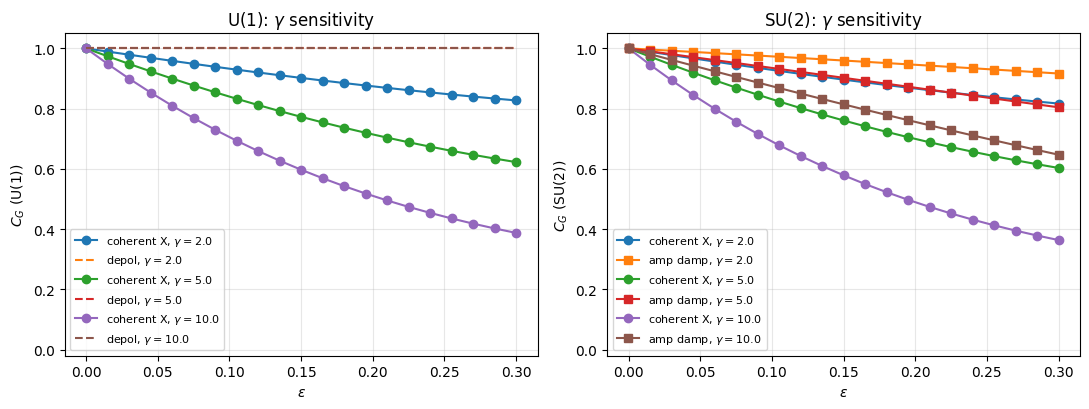

In [ ]:
# ---- Paper Figure 5: gamma sensitivity (SU(2)) ----
# Recompute C_G = exp(-gamma * Delta_G) at multiple gamma values from
# the existing SU(2) defect data, demonstrating that the qualitative
# ordering of channels is preserved across gamma.
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.5))
gammas = CFG["gamma_grid"]
colours = {2.0: "tab:blue", 5.0: "tab:green", 10.0: "tab:purple"}

for g in gammas:
    cgX = [float(np.exp(-g * d)) for d in sweep_su2["coherent_X_q0"]]
    cgA = [float(np.exp(-g * d)) for d in sweep_su2["amp_damp"]]
    ax.plot(eps_grid, cgX, "^-",  color=colours[g],
            label=fr"coherent $X$, $\gamma{{=}}{int(g)}$")
    ax.plot(eps_grid, cgA, "s--", color=colours[g], alpha=0.7,
            label=fr"amp damp, $\gamma{{=}}{int(g)}$")
ax.set_xlabel(r"noise parameter $\varepsilon$")
ax.set_ylabel(r"compliance score $C_G$")
ax.set_ylim(-0.02, 1.05)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.7)
ax.legend(loc="lower left", fontsize=6.5, ncol=2,
          framealpha=0.9, columnspacing=0.8, handlelength=1.4)
ax.grid(alpha=0.3)
plt.tight_layout()
save_paper_figure(fig, "Figure5")
plt.show()


## Section 9: save data tables

In [ ]:
df_sanity_u1.to_csv(os.path.join(CFG["data_dir"], "sanity_u1.csv"), index=False)
df_sanity_su2.to_csv(os.path.join(CFG["data_dir"], "sanity_su2.csv"), index=False)
df_sweep_u1.to_csv(os.path.join(CFG["data_dir"], "sweep_u1.csv"), index=False)
df_sweep_su2.to_csv(os.path.join(CFG["data_dir"], "sweep_su2.csv"), index=False)
df_mixed.to_csv(os.path.join(CFG["data_dir"], "mixed_sweep.csv"), index=False)
df_verdict.to_csv(os.path.join(CFG["data_dir"], "verdict_v.csv"), index=False)
df_R.to_csv(os.path.join(CFG["data_dir"], "verdict_r.csv"), index=False)
df_n3.to_csv(os.path.join(CFG["data_dir"], "robustness_R7_n3.csv"), index=False)
df_stab.to_csv(os.path.join(CFG["data_dir"], "robustness_R6_sampling_stability.csv"), index=False)

print("Saved CSVs to", CFG["data_dir"])
print("Saved figures to", CFG["fig_dir"])